In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

from pathlib import Path

In [40]:
# Load data
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned_2014_2021.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

# Survival: CPC 1-4 = alive, CPC 5 = dead
df['Survived'] = df['Outcome of patient'].astype(str).str.contains("Discharged Alive", na=False).astype(int) & (df['Patient neurological status - Overall'] != 5).astype(int)

Loaded cleaned PAROS dataset: (22706, 75)


/var/folders/y3/l8mcqj111md_2kpwgj8zhk0w0000gn/T/ipykernel_33276/611583221.py:15: DtypeWarning: Columns (5,34,38,44,47,48,49,50,51,52,53,54,61,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEANED_DATASET_PATH)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib,Utstein_Witnessed,Utstein_Rhythm,Utstein_Outcome
0,Ems,2014-01-01,440051.0,NaN,Home Residence,Level 16,65,Years,Female,Chinese,...,NaN,5.0,NaN,2014,2014-01-01 15:14:35,2014-01-01 15:32:10,17.583333,Not Witnessed,Unshockable,Died
1,Ems,2014-01-01,508988.0,NaN,Industrial Place,Level 1,55,Years,Male,Other,...,NaN,5.0,NaN,2014,2014-01-01 06:23:30,NaN,NaN,Bystander Witnessed,Unshockable,Died
2,Ems,2014-01-01,526491.0,NaN,Home Residence,Level 10,85,Years,Female,Chinese,...,NaN,5.0,NaN,2014,2014-01-01 04:47:03,NaN,NaN,Bystander Witnessed,Unshockable,Died


In [41]:
# # Quick validation (optional)
# assert df['Arrest witnessed by'].notna().all(), "Missing witness info"
# assert df['First arrest rhythm'].isin(['Vf','Vt','Unknown Shockable Rhythm']).all(), "Non-shockable present"
# assert (df['Time_to_Defib'] >= 0).all() and (df['Time_to_Defib'] <= 20).all(), "Time_to_Defib out of [0,20]"
# print(f"Validation passed. Cohort size = {len(df)}")

# 1. Filter for Utstein Criteria (Bystander‑witnessed + Shockable)

In [42]:
# Use the final analytic cohort (already filtered for age ≥18, non‑EMS witnessed, shockable)
# But if you want to re‑apply from raw cleaned data:
# bystander_mask = df_cohort['Arrest witnessed by'].str.contains('Bystander', na=False, case=False)
# shockable_mask = df_cohort['First arrest rhythm'].str.contains('Vf|Vt|Shockable', na=False, case=False)
# utstein_df = df_cohort[bystander_mask & shockable_mask].copy()

utstein_df = df.copy()

# 2. Create Binary Survival Column (1 = discharged alive or alive at 30 days)

In [43]:
survival_regex = r'Discharged Alive|Remains In Hospital At 30Th Day Post Arrest'

# Use only 'Patient status' because it contains the definitive outcome
utstein_df['is_survived'] = utstein_df['Patient status'].astype(str).str.contains(
    survival_regex, regex=True, case=False, na=False
).astype(int)

# 3. Bin the Time to Defibrillation (use Time_to_Defib)

In [44]:
time_col = 'Time_to_Defib'   # correct column name

bins = np.arange(0, 22, 2)
midpoints = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

utstein_df['time_bin'] = pd.cut(
    pd.to_numeric(utstein_df[time_col], errors='coerce'),
    bins=bins, labels=midpoints, right=False
)

# 4. Calculate Expected Survival Rate (ESR) per bin

In [45]:
esr_df = utstein_df.groupby('time_bin', observed=False)['is_survived'].mean().reset_index()
esr_df = esr_df.dropna()  # remove any bins with no data

x_vals = esr_df['time_bin'].astype(float)
y_vals = esr_df['is_survived']

# 5. Generate the Paper's Power-Law Curve : y = a * x^b

In [46]:

def power_law(x, a, b):
    return a * (x ** b)

# Fit using curve_fit (log transform could also be used)
popt_power, _ = curve_fit(power_law, x_vals, y_vals, p0=(0.5, -0.5), maxfev=5000)
a_power, b_power = popt_power

# Generate fitted curve
x_power_curve = np.linspace(1, 20, 100)
y_power_curve = power_law(x_power_curve, a_power, b_power)

# R‑squared for power‑law fit
y_pred_power = power_law(x_vals, a_power, b_power)
ss_res_power = np.sum((y_vals - y_pred_power)**2)
ss_tot_power = np.sum((y_vals - np.mean(y_vals))**2)
r2_power = 1 - (ss_res_power / ss_tot_power)

print(f"Power‑law fit: y = {a_power:.4f} * t^{b_power:.4f}, R² = {r2_power:.4f}")

Power‑law fit: y = 0.5301 * t^-0.4539, R² = 0.7403


# 6. Exponential fit: y = a * exp(-b * x)

In [47]:
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

# Fit to binned data (ignore any NaN)
x_fit = x_vals.values
y_fit = y_vals.values

popt, pcov = curve_fit(exp_decay, x_fit, y_fit, p0=(0.5, 0.1), bounds=(0, [1, np.inf]))
a_exp, b_exp = popt

# Generate fitted curve for plotting
x_exp_curve = np.linspace(1, 20, 100)
y_exp_curve = exp_decay(x_exp_curve, a_exp, b_exp)

# R-squared for the exponential fit
residuals = y_fit - exp_decay(x_fit, a_exp, b_exp)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
r2_exp = 1 - (ss_res / ss_tot)

print(f"Exponential fit: a = {a_exp:.4f}, b = {b_exp:.4f}, R² = {r2_exp:.4f}")

Exponential fit: a = 0.5160, b = 0.0968, R² = 0.7869


# 7. Linear fit: y = intercept + slope * x

In [48]:
X_lin = x_vals.values.reshape(-1, 1)
y_lin = y_vals.values

lin_reg = LinearRegression()
lin_reg.fit(X_lin, y_lin)
intercept_lin = lin_reg.intercept_
slope_lin = lin_reg.coef_[0]

# Generate fitted line
x_lin_curve = np.linspace(1, 20, 100)
y_lin_curve = intercept_lin + slope_lin * x_lin_curve

# R-squared for linear fit
y_pred_lin = lin_reg.predict(X_lin)
ss_res_lin = np.sum((y_lin - y_pred_lin)**2)
ss_tot_lin = np.sum((y_lin - np.mean(y_lin))**2)
r2_lin = 1 - (ss_res_lin / ss_tot_lin)

print(f"Linear fit: survival = {intercept_lin:.4f} + {slope_lin:.4f} * time, R² = {r2_lin:.4f}")

Linear fit: survival = 0.4340 + -0.0206 * time, R² = 0.7410


# 8. Plot

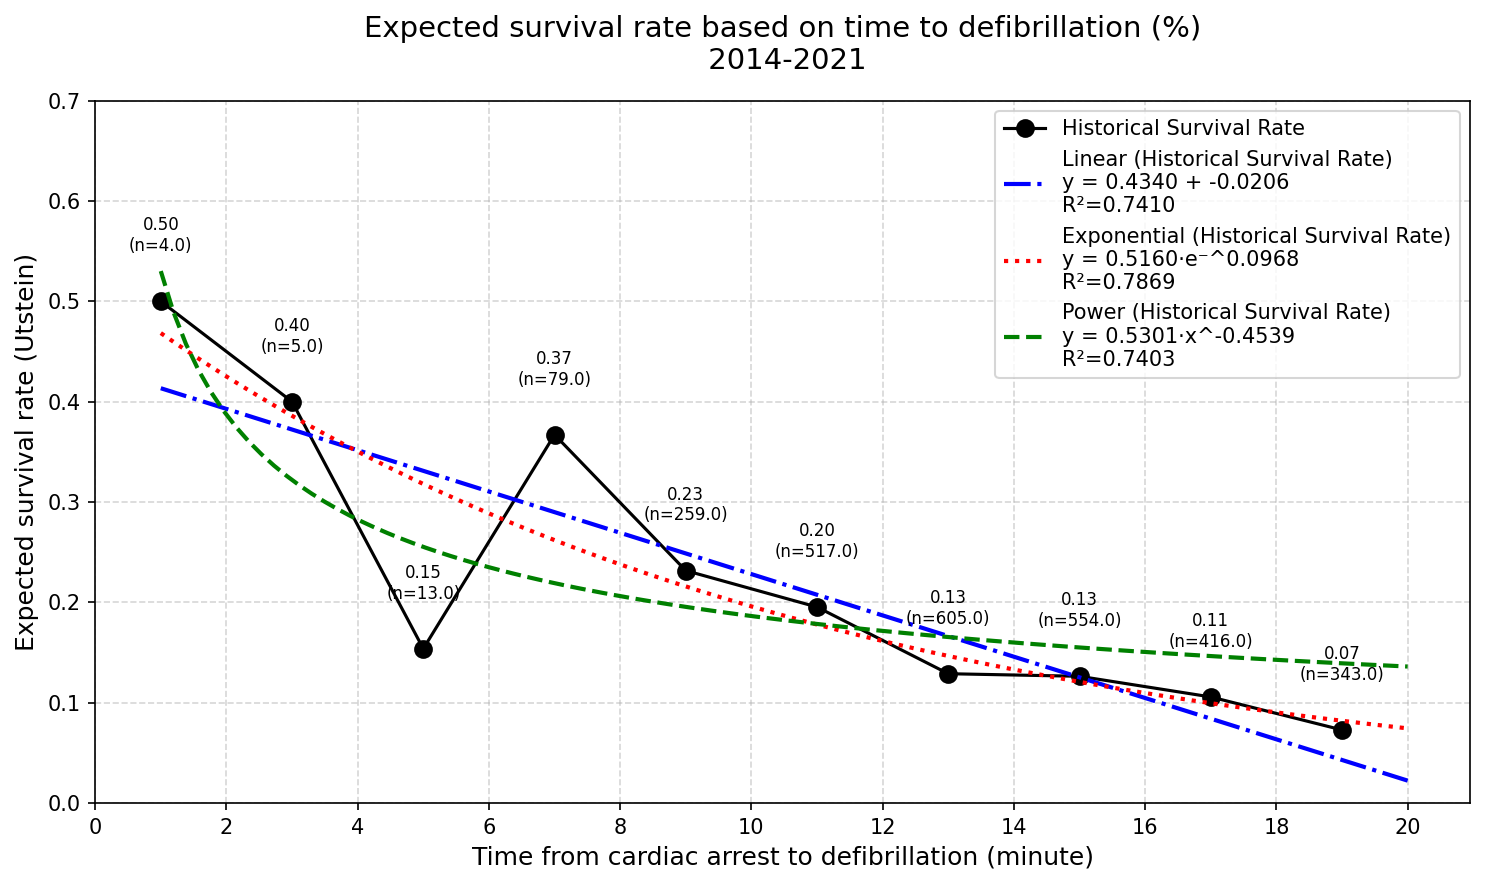

In [49]:
plt.figure(figsize=(10,6), dpi=150)

# Observed data
plt.plot(x_vals, y_vals, marker='o', markersize=8, linestyle='-', color='black', label='Historical Survival Rate')

# Linear fitted line
plt.plot(x_lin_curve, y_lin_curve, linestyle='-.', color='blue', linewidth=2,
         label=f'Linear (Historical Survival Rate)\ny = {intercept_lin:.4f} + {slope_lin:.4f}\nR²={r2_lin:.4f}')
         
# Exponential fitted curve
plt.plot(x_exp_curve, y_exp_curve, linestyle=':', color='red', linewidth=2,
         label=f'Exponential (Historical Survival Rate)\ny = {a_exp:.4f}·e⁻^{b_exp:.4f}\nR²={r2_exp:.4f}')

# Power-law fitted curve
plt.plot(x_power_curve, y_power_curve, linestyle='--', color='green', linewidth=2,
         label=f'Power (Historical Survival Rate)\ny = {a_power:.4f}·x^{b_power:.4f}\nR²={r2_power:.4f}')

# Calculate n per bin
n_per_bin = utstein_df.groupby('time_bin', observed=False)['is_survived'].count().reset_index()
n_per_bin.columns = ['time_bin', 'n']

# Merge with esr_df to get both survival and n
esr_with_n = esr_df.merge(n_per_bin, on='time_bin')

# Annotations
for _, row in esr_with_n.iterrows():
    x = row['time_bin']
    y = row['is_survived']
    n = row['n']
    plt.text(x, y + 0.05, f'{y:.2f}\n(n={n})', ha='center', fontsize=8)

plt.title('Expected survival rate based on time to defibrillation (%)\n 2014-2021', fontsize=14, pad=15)
plt.xlabel('Time from cardiac arrest to defibrillation (minute)', fontsize=12)
plt.ylabel('Expected survival rate (Utstein)', fontsize=12)
plt.xticks(np.arange(0, 22, 2))
plt.ylim(0, 0.70)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CURRENT_DIRECTORY / "Utstein_Survival_Curve_2014_2021.png", dpi=300)
plt.show()


In [50]:
# 1. Check your Utstein Sample Size
print(f"Total Utstein Cohort: {len(utstein_df)}")

# 2. Check the distribution of your Time Bins
print("\nPatient count per 2-minute bin:")
print(esr_with_n[['time_bin', 'n']])

# 3. Check Etiologies
if 'Cause of arrest' in utstein_df.columns:
    print("\nCause of Arrest breakdown in Utstein cohort:")
    print(utstein_df['Cause of arrest'].value_counts(dropna=False))

# 4. Check Utstein Core Variables (per 2-minute bin)
print("\n--- Utstein Core Variables Breakdown Per Bin ---")

for bin_label in sorted(utstein_df['time_bin'].dropna().unique()):
    bin_df = utstein_df[utstein_df['time_bin'] == bin_label]
    
    print(f"\n=== TIME BIN: {bin_label} (n={len(bin_df)}) ===")
    
    # Witnessed Status
    not_witnessed = bin_df['Arrest witnessed by'].astype(str).str.contains('Not Witnessed', regex=False).sum()
    bystander_witnessed = bin_df['Arrest witnessed by'].astype(str).str.contains('Bystander - Family|Bystander - Lay Person|Bystander - Healthcare Provider', regex=True).sum()
    ems_witnessed = bin_df['Arrest witnessed by'].astype(str).str.contains('Ems/Private Ambulance', regex=False).sum()
    unknown_witnessed = len(bin_df) - (not_witnessed + bystander_witnessed + ems_witnessed)

    print("Witnessed Status:")
    print(f"  Bystander Witnessed: {bystander_witnessed}")
    print(f"  Not Witnessed: {not_witnessed}")
    print(f"  EMS Witnessed: {ems_witnessed}")
    print(f"  Unknown: {unknown_witnessed}")

    # First Rhythm
    shockable = bin_df['First arrest rhythm'].astype(str).str.contains('Vf|Vt|Unknown Shockable Rhythm', regex=True).sum()
    unshockable = bin_df['First arrest rhythm'].astype(str).str.contains('Asystole|Pea|Unknown Unshockable Rhythm', regex=True).sum()
    unknown_rhythm = len(bin_df) - (shockable + unshockable)

    print("First Rhythm:")
    print(f"  Shockable: {shockable}")
    print(f"  Unshockable: {unshockable}")
    print(f"  Unknown: {unknown_rhythm}")

    # Outcome
    died = (bin_df['Outcome of patient'].astype(str).str.contains('Died In Ed', regex=False) | 
            bin_df['Patient status'].astype(str).str.contains('Died In The Hospital', regex=False)).sum()
    discharged_alive = bin_df['Patient status'].astype(str).str.contains('Discharged Alive', regex=False).sum()
    inhospital_30days = bin_df['Patient status'].astype(str).str.contains('Remains In Hospital At 30Th Day Post Arrest', regex=False).sum()
    unknown_outcome = len(bin_df) - (died + discharged_alive + inhospital_30days)

    print("Outcome Counts:")
    print(f"  Died: {died}")
    print(f"  Discharged Alive: {discharged_alive}")
    print(f"  In Hospital After 30 Days: {inhospital_30days}")
    print(f"  Unknown: {unknown_outcome}")

Total Utstein Cohort: 22706

Patient count per 2-minute bin:
  time_bin    n
0        1    4
1        3    5
2        5   13
3        7   79
4        9  259
5       11  517
6       13  605
7       15  554
8       17  416
9       19  343

Cause of Arrest breakdown in Utstein cohort:
Cause of arrest
NaN           21522
Non-Trauma     1184
Name: count, dtype: int64

--- Utstein Core Variables Breakdown Per Bin ---

=== TIME BIN: 1 (n=4) ===
Witnessed Status:
  Bystander Witnessed: 3
  Not Witnessed: 0
  EMS Witnessed: 1
  Unknown: 0
First Rhythm:
  Shockable: 2
  Unshockable: 1
  Unknown: 1
Outcome Counts:
  Died: 2
  Discharged Alive: 2
  In Hospital After 30 Days: 0
  Unknown: 0

=== TIME BIN: 3 (n=5) ===
Witnessed Status:
  Bystander Witnessed: 3
  Not Witnessed: 1
  EMS Witnessed: 1
  Unknown: 0
First Rhythm:
  Shockable: 5
  Unshockable: 0
  Unknown: 0
Outcome Counts:
  Died: 3
  Discharged Alive: 2
  In Hospital After 30 Days: 0
  Unknown: 0

=== TIME BIN: 5 (n=13) ===
Witnessed Sta